In [1]:
import numpy as np
import os
from matplotlib import pyplot as plt

In [2]:
freq_code_u_to_hz = 203000

In [13]:
eos_colors = {"BA": "red",
              "DD2F-SF1": "black",
              "DD2": "orange",
              "BHBlp": "green",
              "SFHo": "purple",
              "BLQ": "gold",
              "SLy4": "turquoise",
              "DD2F": "slategray",
              "BLh": "darkgreen",
              "LS220": "plum",
              }

core_subeos = {
              "DD2": "brown",
              "BHBlp": "green",
              "BLQ": "purple",
              "BLh": "black",
              "LS220": "red"}


In [3]:
RVSS_List = {"V" : ['red',0.0039],  
             "IV" : ['purple',0.0027],
             "III" : ['blue',0.0021],
             "II": ['green',0.0017],
             "I": ['black',0.0012]}   

In [4]:
RVSS_f2_list_1p4 = np.asarray([2.3183139534883717, 2.935739436619718, 0.7318230115361263, 0.7441348973607038])
RVSS_f2_list_1p3 = np.asarray([2.2601524758454103, 2.837993421052632, 3.1352294608472397, 0.71104410331384, 2.5674536256323774])
RVSS_f2_list_1p35 = np.asarray([2.640295504994450315e+00])

RVSS_Mf2_list_1p3 = (2.6)*(RVSS_f2_list_1p3)*1000/freq_code_u_to_hz
RVSS_Mf2_list_1p4 = (2.8)*(RVSS_f2_list_1p4)*1000/freq_code_u_to_hz
RVSS_Mf2_list_1p35 = (2.7)*(RVSS_f2_list_1p35)*1000/freq_code_u_to_hz


In [5]:
core_mvr_data = {}

for file in os.listdir('./MVR/CORE'):
    file_split = file.split("_")
    eos = file_split[0]
    mvr_data = np.loadtxt(f'./MVR/CORE/{file}',skiprows=1)
    core_mvr_data[eos] = mvr_data
    print(eos)

BLh
DD2F
DD2F-SF1
LS220
BHBlp
DD2
SLy4
BA
BLQ
SFHo


In [6]:
rvss_mvr_data = {}

for file in os.listdir('./MVR/RVSS'):
    file_split = file.split('_')
    model = file_split[0]
    rvss_mvr_data[model] = np.loadtxt(f'./MVR/RVSS/{file}',skiprows=1)
    print(model)

I
V
III
IV
II


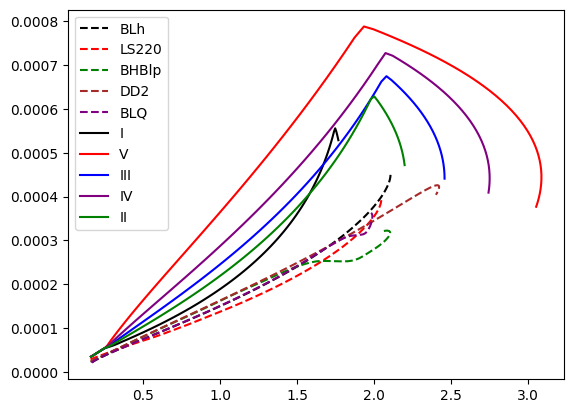

In [20]:
for eos in core_mvr_data:
    if eos in core_subeos:
        data = core_mvr_data[eos]
        M = data[:,0]
        R = data[:,1]
        cs2_mub_Vavg = data[:,6]
        mub_cs2p_Vavg = data[:,7]
        plt.plot(M,cs2_mub_Vavg,color=core_subeos[eos],label=eos,linestyle = '--')
for model in rvss_mvr_data:
    data_RVSS = rvss_mvr_data[model]
    M = data_RVSS[:,0]
    R = data_RVSS[:,1]
    cs2_mub_Vavg = data_RVSS[:,5]
    mub_cs2p_Vavg = data_RVSS[:,6]
    plt.plot(M,cs2_mub_Vavg,label=model,color=RVSS_List[model][0])
plt.legend()



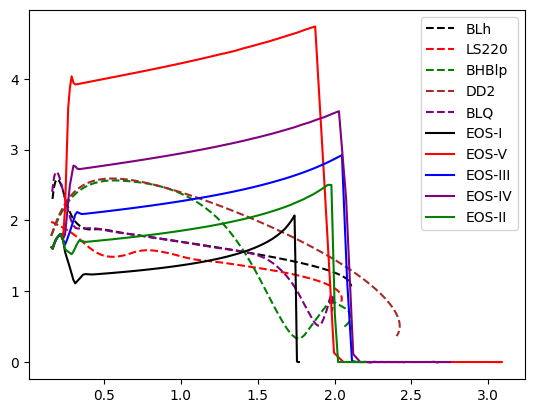

In [ ]:
cs2p_mub_fig,csp_mub_axes = plt.subplots()
for eos in core_mvr_data:
    if eos in core_subeos:
        data = core_mvr_data[eos]
        M = data[:,0]
        R = data[:,1]
        mub_cs2p_Vavg = data[:,7]
        csp_mub_axes.plot(M,mub_cs2p_Vavg,color=core_subeos[eos],linestyle = '--',label=eos)
for model in rvss_mvr_data:
    data_RVSS = rvss_mvr_data[model]
    M = data_RVSS[:,0]
    R = data_RVSS[:,1]
    mub_cs2p_Vavg = data_RVSS[:,6]
    csp_mub_axes.plot(M,mub_cs2p_Vavg,color=RVSS_List[model][0],label=f"EOS-{model}")
csp_mub_axes.legend()

